<font size=6><b>Lec03.딥러닝 모델 - 회귀

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#----------------------------------------------------------------------------------- ML 모델
from xgboost import XGBRegressor 
#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <B>Data Load

In [2]:
df = pd.read_csv("../ml/datas/lec06_boston-house-price-data.csv")
df.columns = df.columns.str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [3]:
df.head(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


# <b> 회귀 모델 점수

In [4]:
y = df['medv']
X = df.drop('medv', axis=1)
print(X.shape,  y.shape)

X80,X20,y80,y20 = train_test_split(X, y, random_state=7825 )
print(X80.shape,X20.shape,y80.shape,y20.shape)

(506, 13) (506,)
(379, 13) (127, 13) (379,) (127,)


In [5]:
model = XGBRegressor(random_state=4567) 
model.fit(X80, y80)
pred  = model.predict(X20)

mse       = mean_squared_error(y20        , pred)
rmse      = np.sqrt(mse)
print(f"mse:{mse:.4f}\t rmse:{rmse:.4f}")
print()

mse:9.0452	 rmse:3.0075



# <b> 딥러닝 모델 점수

In [6]:
model = Sequential([
    Dense(units=10, activation="relu" , input_dim=13 ),   #----- input layer
    Dense(units=16, activation="relu"                ),   #----- hidden layer 3
    Dense(units=24, activation="relu"                ),    
    Dense(units=8,  activation="relu"                ),
    Dense(units=1                                    )    #----- output layer   
 ])

In [7]:
model.compile(loss="mse", optimizer="adam",  metrics=["mse"])   #-------------------- l o m

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 933 (3.64 KB)

 Trainable params: 933 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
res = model.fit(X80,y80,     epochs=50 ,   validation_data = (X20,y20)  )
# res
loss,mse = model.evaluate(X20, y20)
print(f"mse : {mse:.4f} , loss:{loss:.4f} , rmse : {np.sqrt(mse):.4f} " )

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 599.0286 - mse: 599.0286 - val_loss: 335.0281 - val_mse: 335.0281
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 248.6369 - mse: 248.6369 - val_loss: 137.6394 - val_mse: 137.6394
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 114.6682 - mse: 114.6682 - val_loss: 116.1094 - val_mse: 116.1094
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 109.6785 - mse: 109.6785 - val_loss: 107.7749 - val_mse: 107.7749
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 95.7495 - mse: 95.7495 - val_loss: 86.0225 - val_mse: 86.0225
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 85.8207 - mse: 85.8207 - val_loss: 73.3842 - val_mse: 73.3842
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 78.1568 - mse: 78.1568 - val_loss: 67.4501 - val_mse: 67.4501
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 73.8797 - mse: 73.8797 - val_loss: 61.5574 - val_mse: 61.5574
Epoch 9/50
12/12 ━━━━━━

In [10]:
res.history.keys()  
#res.history['accuracy']

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

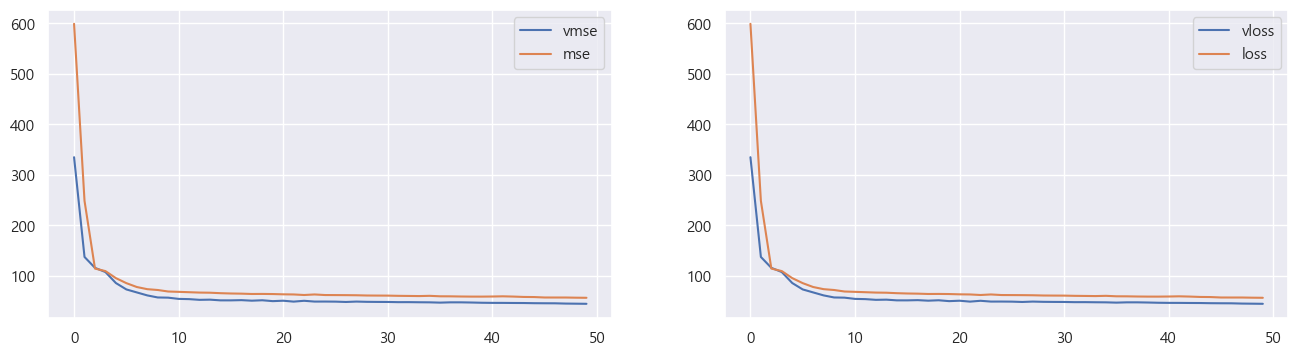

In [11]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_mse"]
acc  = res.history["mse"]
plt.plot(range(50), vacc , label="vmse")
plt.plot(range(50), acc  , label="mse")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(50),vloss , label="vloss")
plt.plot(range(50),loss  , label="loss")
plt.legend()
plt.show()